# Q1

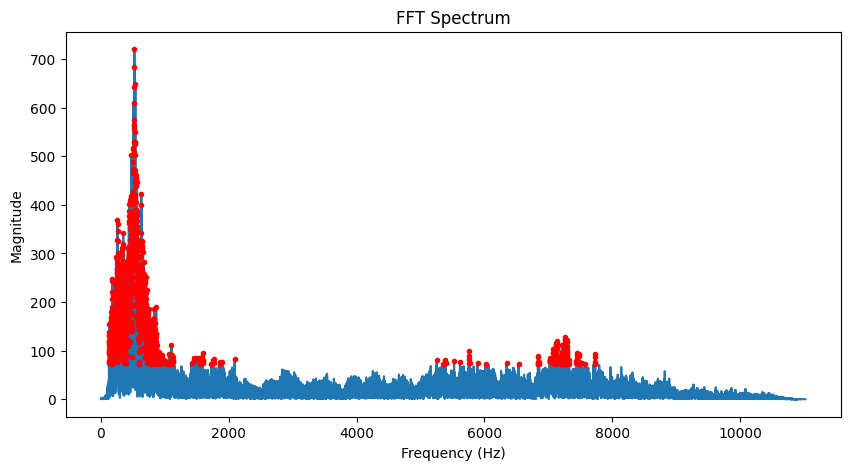

124.57357976947922


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import find_peaks

fs, signal = wavfile.read('LJ025-0076.wav')
signal = signal / np.max(np.abs(signal))
signal = signal[:len(signal)//2]

N = len(signal)
fft_vals = np.fft.fft(signal)
fft_vals = np.abs(fft_vals[:N//2])
freqs = np.fft.fftfreq(N, 1/fs)[:N//2]

peaks, _ = find_peaks(fft_vals, height=np.max(fft_vals)*0.1)

plt.figure(figsize=(10,5))
plt.plot(freqs, fft_vals)
plt.plot(freqs[peaks], fft_vals[peaks], 'r.')
plt.title("FFT Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

pitch = freqs[peaks[0]]
print(pitch)

# Q2

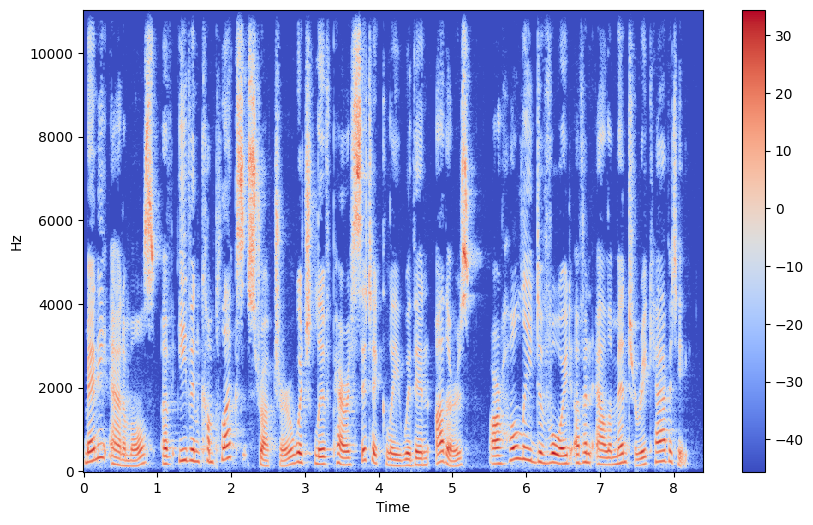

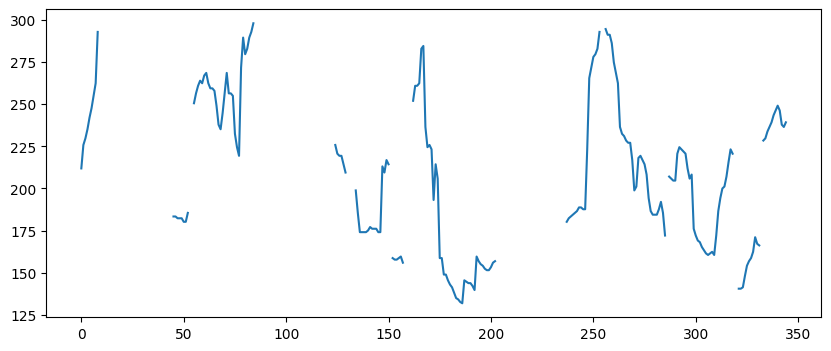

In [4]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

signal, fs = librosa.load('LJ025-0076.wav', sr=None)

D = librosa.stft(signal, n_fft=1024, hop_length=256)
S_db = librosa.amplitude_to_db(abs(D))

plt.figure(figsize=(10,6))
librosa.display.specshow(S_db, sr=fs, hop_length=256, x_axis='time', y_axis='hz')
plt.colorbar()
plt.show()

f0, voiced_flag, voiced_probs = librosa.pyin(signal, fmin=50, fmax=300)

plt.figure(figsize=(10,4))
plt.plot(f0)
plt.show()

# Q3

In FFT, pitch is the first peak and harmonics are equally spaced peaks. Formants appear as spectral envelope.

In STFT, pitch appears as horizontal lines and formants appear as dark bands.

Pitch and harmonics are clearer in FFT, while formants are clearer in STFT.

# Q4

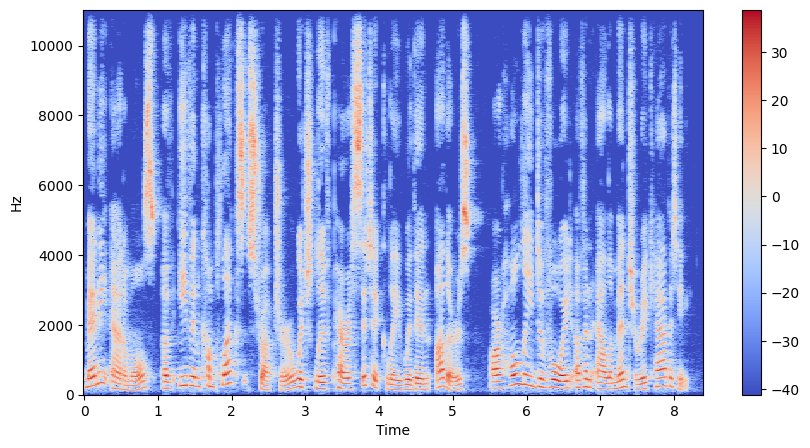

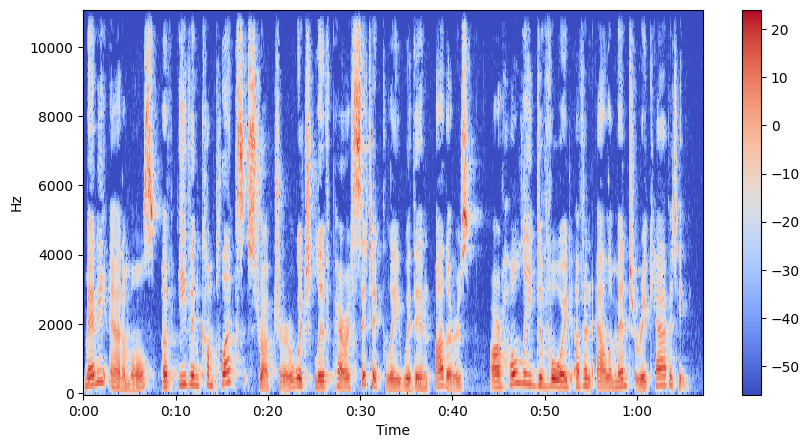

In [5]:
D_narrow = librosa.stft(signal, n_fft=2048, hop_length=512)
S_narrow = librosa.amplitude_to_db(abs(D_narrow))

plt.figure(figsize=(10,5))
librosa.display.specshow(S_narrow, sr=fs, x_axis='time', y_axis='hz')
plt.colorbar()
plt.show()

D_wide = librosa.stft(signal, n_fft=256, hop_length=64)
S_wide = librosa.amplitude_to_db(abs(D_wide))

plt.figure(figsize=(10,5))
librosa.display.specshow(S_wide, sr=fs, x_axis='time', y_axis='hz')
plt.colorbar()
plt.show()

# Q5

Narrowband gives better frequency resolution and shows harmonics clearly.

Wideband gives better time resolution and shows formants clearly.

There is a trade-off between time and frequency resolution.